# Unit 4 : Machin Learning
```
 -->  supervised learning
 ------------------------ after sem 6---------------------
 --> unsupervised learning 
 --> Semi-Supervise Learning
 --> Reinforced Learning -- For robots or Ai
```

## Regression

### Simple Linear Regression y = mx + c

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df  = pd.read_csv("Book2.csv")
df

,X,Y
0,11,70
1,19,85
2,12,73
3,18,82
4,13,74
5,17,80
6,14,76
7,16,79
8,15,78
9,20,89


<Axes: xlabel='X', ylabel='Y'>

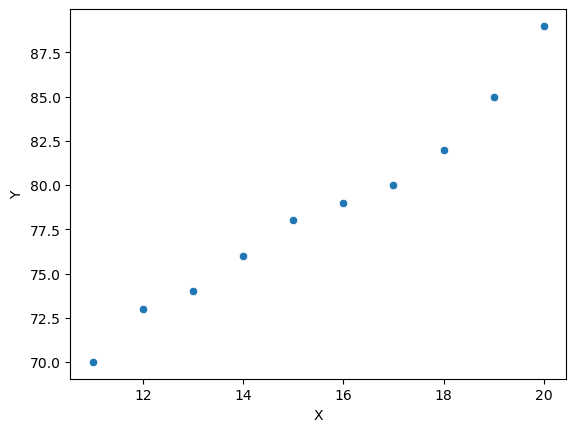

In [3]:
sns.scatterplot(df,x="X",y="Y")

<Axes: xlabel='X', ylabel='Y'>

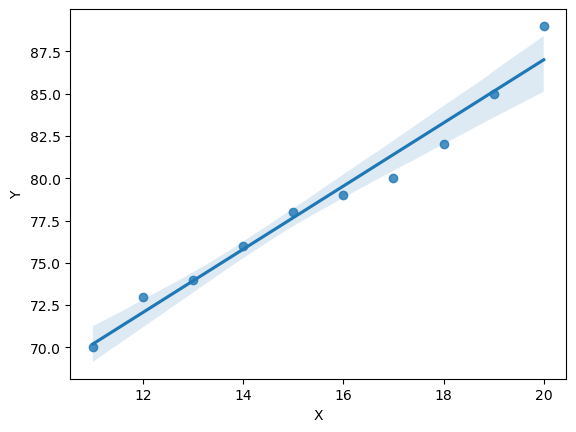

In [4]:
sns.regplot(df,x="X",y="Y")

In [5]:
#difference called residuals error actual value - predicted value
x = df[['X']]
y = df[['Y']]


In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(x,y)

LinearRegression()

In [8]:
# Give vaule of M - slope
print(lr.coef_)

[[1.86666667]]


In [9]:
# Give value of Constant
print(lr.intercept_)

[49.66666667]


<Axes: xlabel='X', ylabel='Y'>

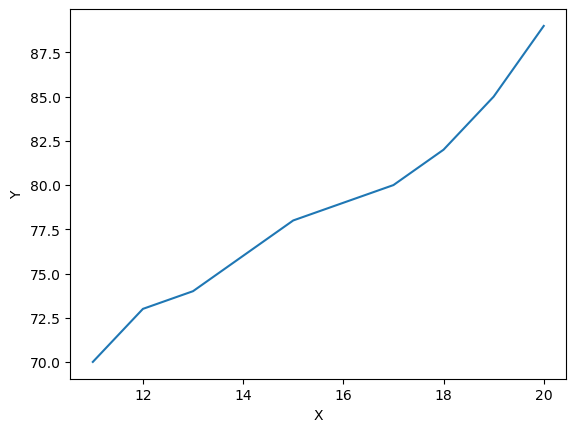

In [10]:
sns.lineplot(df,x="X",y="Y")

In [11]:
print(lr.predict([[18]]))

[[83.26666667]]


c:\Users\vdp87\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [13]:
y_pred = lr.predict(x)

In [14]:
print(mean_absolute_error(y,y_pred))
print(mean_squared_error(y,y_pred))
print(r2_score(y,y_pred))

0.7066666666666649
0.8933333333333279
0.9698605488079174


In [15]:
df = pd.read_csv("Book1.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


<Axes: xlabel='cgpa', ylabel='package'>

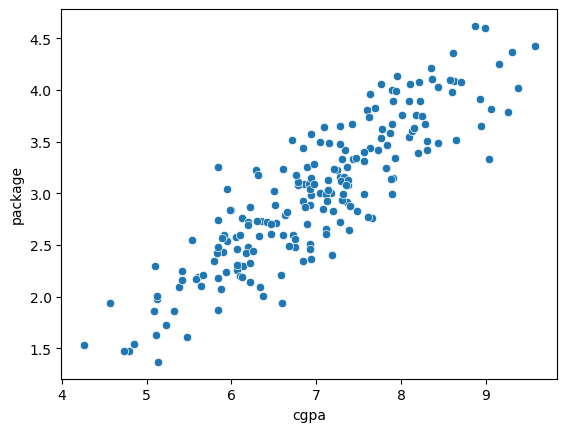

In [16]:
sns.scatterplot(df,x="cgpa",y="package")

<Axes: xlabel='cgpa', ylabel='package'>

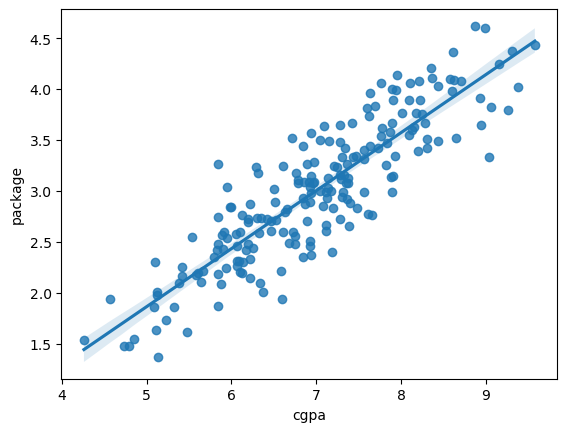

In [17]:

sns.regplot(df,x="cgpa",y="package")

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [19]:
df["brand"]= df['name'].apply(lambda x: x.split()[0])
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [20]:
df['age']= 2026 - df['year']
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [21]:
df.drop(columns=['name','year'],axis=1,inplace=True)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [22]:
df = pd.get_dummies(df,drop_first=True)
df.shape

(4340, 42)

In [23]:
x = df.drop(columns=['selling_price'],axis=1)
y = df['selling_price']


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10) 
model = LinearRegression()
model.fit(x_train,y_train)



LinearRegression()

In [26]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_absolute_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

175284.62042882253
0.708424022397538


In [27]:
r2 = []
for i in range(0,43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=i)
    model = LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    r2.append(r2_score(y_test,y_pred))
print(max(r2))
print(r2.index(max(r2)))

0.7559672193277194
25


In [28]:
df = pd.read_csv("insurance.csv")


In [29]:
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.92400
1,18,male,33.77,1,no,southeast,1725.55230
2,28,male,33,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.88,0,no,northwest,3866.85520


In [30]:
df = df.loc[df['bmi']!='-']
df['bmi'] = df['bmi'].astype(float)

In [31]:
df = pd.get_dummies(df,drop_first=True)
df.head()

,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [32]:
x = df.drop(columns=['charges'],axis=1)
y = df['charges']   

r2 = []
r2 = []
for i in range(0,43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=i)
    model = LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    r2.append(r2_score(y_test,y_pred))
print(max(r2))
print(r2.index(max(r2)))


0.8219565449935415
11


In [33]:
df = pd.read_csv("Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [35]:
df.drop(columns=['No'],inplace=True)
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [36]:
df.isna().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [37]:

x = df[["X1 transaction date","X2 house age",'X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude']]
y = df ['Y house price of unit area']

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.3,random_state=110)


In [39]:
model = LinearRegression()
model.fit(x_train,y_train)



LinearRegression()

In [40]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test,y_pred))
print(model.coef_)

6.32947801592832
[-1.02029605e-01 -3.66729256e-01 -2.65639510e-03  1.24922545e+00
  2.75111550e+02  6.17948752e+01]


In [41]:
df = pd.read_csv("Ice_cream selling data.csv")

In [42]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [43]:
x = df[['Temperature (°C)']]
y = df ["Ice Cream Sales (units)"]

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=110)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import mean_absolute_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(model.coef_)

-0.594085841318724
12.565436719251911
[0.39824154]


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

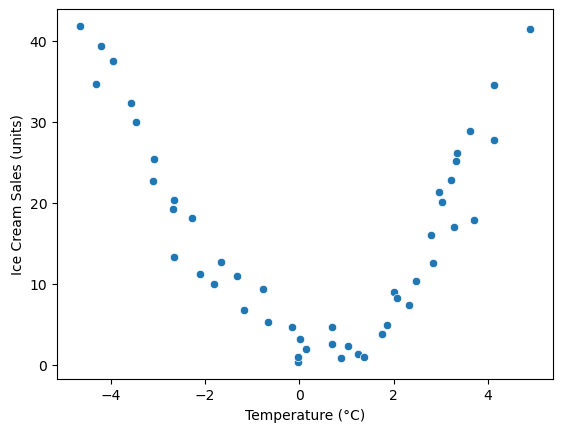

In [44]:
import seaborn as sns
sns.scatterplot(df,x=df["Temperature (°C)"],y=y)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

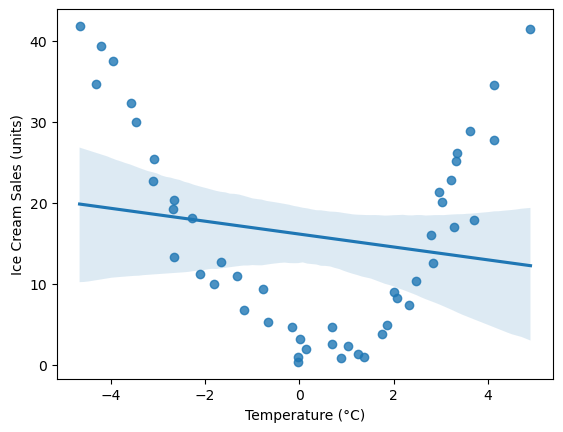

In [45]:
sns.regplot(df,x=df["Temperature (°C)"],y=y)

In [46]:
x = df[['Temperature (°C)']]
y = df ["Ice Cream Sales (units)"]

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=10)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
x_train_poly # y = ax^2 + bx + c

array([[ 1.00000000e+00,  2.83176021e+00,  8.01886589e+00],
       [ 1.00000000e+00,  1.49244574e-01,  2.22739429e-02],
       [ 1.00000000e+00,  3.33593241e+00,  1.11284451e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -3.61564977e-02,  1.30729232e-03],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -3.08130332e+00,  9.49443018e+00],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00]])

```
x1,x2,x3
y
y = m1x1^2 +m2x2^2 +m3x3^2 +m4x1x2+m5x2x3+m6x3x1+m7x1+m8x2+m9x3+m10b

n = no. of features
d = no. of features 

(n+d)!/(n!*d!)

5!/3!*2! -- 120/12 --10
```

In [47]:
df = pd.read_csv('insurance.csv')
df = df.loc[df['bmi']!='-']
df['bmi'] = df['bmi'].astype("float")
df = pd.get_dummies(df,drop_first=True)
x = df.drop('charges',axis=1)
y = df['charges']

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=10)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [48]:
model = LinearRegression()
model.fit(x_train_poly,y_train)
y_pred = model.predict(x_test_poly)
print(model.coef_)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
from sklearn.metrics import  mean_squared_error
print(mean_squared_error(y_test,y_pred))


[ 2.79325672e-08  2.73200163e+02  1.05066302e+03 -3.17863207e+02
 -2.64154377e+03 -1.05731968e+04  3.58679975e+03  3.04445363e+03
  2.43501833e+03  4.89865291e-01 -1.98069772e+00 -3.67255410e+00
  5.35454074e+01 -1.54485743e+01 -2.99559643e+01  4.65719235e+01
  4.81591995e+01 -1.12423305e+01 -5.84537495e+00 -2.31734760e+01
  1.53657435e+03 -2.89216457e+02 -3.15252562e+02 -3.34812459e+02
  1.97104047e+02  4.64612432e+02 -5.15588789e+01  6.48001509e+02
 -8.39071922e+02  4.93355317e+02 -2.64154377e+03  1.22529774e+03
  4.18096433e+03  3.94597963e+03  2.49384590e+03 -1.05731968e+04
 -2.58834315e+03 -2.38311956e+03 -1.99797128e+03  3.58679975e+03
  0.00000000e+00  0.00000000e+00  3.04445363e+03  0.00000000e+00
  2.43501833e+03]
3252.13943228291
0.8218457762006321
25864018.197504036


# Cross -Validation

In [49]:
import pandas as pd
df = pd.read_csv("Advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [50]:
y= df['Sales']
x = df.drop(columns=['Sales'],axis=1)


In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
scores = cross_val_score(model,x,y,cv=5,scoring='neg_mean_absolute_error')
print(-scores.mean())

1.2683048324460453


In [52]:
# pollynomial reg using cross validation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
model = Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('model',LinearRegression())
])
scores = cross_val_score(model,x,y,cv=5,scoring='neg_mean_absolute_error')
print(-scores.mean())

1.0676311206110323


In [53]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
model = {
    'LinearRegression':LinearRegression(),
    'Polynomial (degree,2)':Pipeline([
        ('poly',PolynomialFeatures(degree=2)),
        ('model',LinearRegression())
    ]),
    'ridge':Ridge(),
    'Lasso':Lasso(),
    'Random Forest' : RandomForestRegressor(random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(random_state=42)
}

results = []
for name,model in model.items():
    scores = cross_val_score(model,x,y,cv=5,scoring='r2')
    mae = scores.mean()
    results.append((name,mae))
print(results)
    

[('LinearRegression', np.float64(0.8953723525274103)), ('Polynomial (degree,2)', np.float64(0.9253831326253561)), ('ridge', np.float64(0.8953725201883931)), ('Lasso', np.float64(0.8957161899613204)), ('Random Forest', np.float64(0.9416604403430396)), ('Gradient Boosting', np.float64(0.9385782396608894))]


```
Write a python program for following tasks - 
Make sure all the required libraries are imported at the beginning of the Jupyter Notebook.
 a)Load the windpower dataset into the notebook.
 b)Check records for any missing values and remove them permanently using appropriate method.
 c)Treat windspeed as the independent variable and power as the dependent variable. Split the dataset into training (75%) and 
testing (25%) sets using random state of 42.
 d)Use scikit-learn to train polynomial regression models of degrees 3, 4, 5, and 6.
 e)Predict power values on the test set and print the Mean Squared Error (MSE) and R² score (coefficient of determinaƟon) for 
each polynomial degree.
 f)Plot actual vs. predicted power values for all polynomial degrees on the same graph for comparison and label the plot 
accordingly.
 g)Create a plot showing MSE vs. polynomial degree. Which degree has the lowest MSE? Write in the comment.
 h)Print the coefficients and intercept for each trained polynomial regression mode
```

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [55]:
df = pd.read_csv('windpower.csv')
df.head()

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275


In [56]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [57]:
df.dropna(inplace=True)

In [58]:
x = df[['Wind speed (m/s)']]
y = df['Power (kW)']


In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [60]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
predictions = []
mse =[]
predictions.append(y_test)
for i in range(3,7):
    poly = PolynomialFeatures(degree=i)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
    model = LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred = model.predict(x_test_poly)
    predictions.append(y_pred)
    print(f"The coefficients for degress {i} are,",model.coef_)
    print(f"The intercepts for degress {i} is",model.intercept_)
    print(f"The MSE for degress {i} is",mean_squared_error(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))
    print(f"The R2 score  for degress {i} is",r2_score(y_test,y_pred))
    x_new = pd.DataFrame({'Wind speed (m/s)':[5,10,15,20]})
    x_new_poly = poly.transform(x_new)
    y_new = model.predict(x_new_poly)
    print(f"Predcted values of power for wind speed 5,10,15,20 for degree {i} is",y_new)
    print("-----------------------------------------------------------------------------")

The coefficients for degress 3 are, [  0.         -12.17377575   1.8029668   -0.04960797]
The intercepts for degress 3 is 17.77534233104104
The MSE for degress 3 is 270.02500952999515
The R2 score  for degress 3 is 0.8539264141973834
Predcted values of power for wind speed 5,10,15,20 for degree 3 is [-4.22036222 26.72629808 73.40934798 98.62281223]
-----------------------------------------------------------------------------
The coefficients for degress 4 are, [ 0.         -2.10494179 -0.036268    0.06568915 -0.00231786]
The intercepts for degress 4 is 5.863727006131917
The MSE for degress 4 is 209.31845107865263
The R2 score  for degress 4 is 0.8867664266471883
Predcted values of power for wind speed 5,10,15,20 for degree 4 is [  1.19480184  23.69809951  70.4887228  103.91393443]
-----------------------------------------------------------------------------


The coefficients for degress 5 are, [ 0.00000000e+00 -6.91240269e-01 -4.31617906e-01  1.07790122e-01
 -4.21343552e-03  3.03911610e-05]
The intercepts for degress 5 is 4.739942925872477
The MSE for degress 5 is 212.42288613290617
The R2 score  for degress 5 is 0.8850870416115004
Predcted values of power for wind speed 5,10,15,20 for degree 5 is [  1.42863436  23.36063257  70.82208666 103.69098368]
-----------------------------------------------------------------------------
The coefficients for degress 6 are, [ 0.00000000e+00  2.39063436e+01 -1.00641730e+01  1.62983192e+00
 -1.17629556e-01  4.01186376e-03 -5.30687163e-05]
The intercepts for degress 6 is -9.91662057869683
The MSE for degress 6 is 169.17010396377796
The R2 score  for degress 6 is 0.9084852038720306
Predcted values of power for wind speed 5,10,15,20 for degree 6 is [-7.08347637e-02  2.43835318e+01  7.19492440e+01  1.02033579e+02]
-----------------------------------------------------------------------------


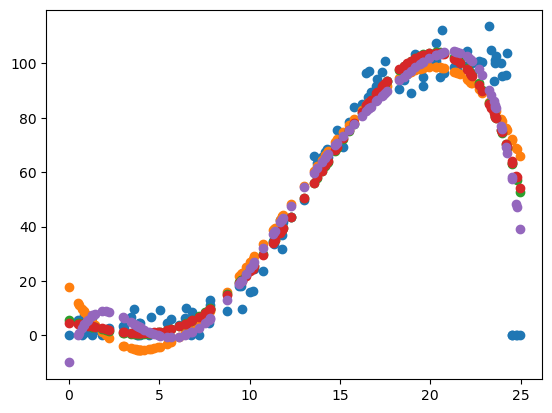

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in predictions:
    plt.scatter(x_test,i)
plt.show()

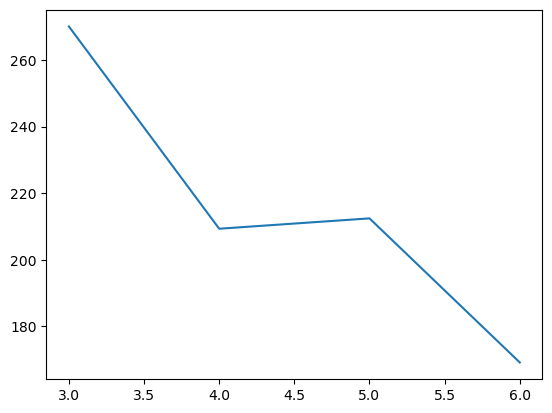

In [62]:
deg = [3,4,5,6]
plt.plot(deg,mse)
plt.show()

In [63]:
df = pd.read_csv('Marksheet.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sr no         302 non-null    int64  
 1   Branch        302 non-null    object 
 2   Enrolment No  302 non-null    float64
 3   Name          302 non-null    object 
 4   Roll No       302 non-null    int64  
 5   Div           302 non-null    object 
 6   Mentor Name   301 non-null    object 
 7   TEST-1 MARKS  302 non-null    float64
 8   TEST-2 MARKS  302 non-null    float64
 9   TEST-3 MARKS  302 non-null    object 
 10  TEST-4 MARKS  302 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 26.1+ KB


In [64]:
df['TEST-3 MARKS'] = df['TEST-3 MARKS'].replace('AB',0)
df['TEST-4 MARKS'] = df['TEST-4 MARKS'].replace('AB',0)
df['TEST-3 MARKS'] = df['TEST-3 MARKS'].astype('float')
df['TEST-4 MARKS'] = df['TEST-4 MARKS'].astype('float')

In [65]:
df["Total Marks"]= df['TEST-1 MARKS']+df['TEST-2 MARKS']+df['TEST-3 MARKS']+df['TEST-4 MARKS']

In [66]:
df.head()

,sr no,Branch,Enrolment No,Name,Roll No,Div,Mentor Name,TEST-1 MARKS,TEST-2 MARKS,TEST-3 MARKS,TEST-4 MARKS,Total Marks
0,1,CE,2.200220e+13,KATHIRIYA VRAJKUMAR ASHVINBHAI,110,A4,UMM,22.5,18.0,22.5,14.5,77.5
1,2,CE,2.300220e+13,AGRAVAT SAHIL RAJARAMBHAI,101,A3,SAS,21.5,20.0,19.0,14.0,74.5
2,3,CE,2.300220e+13,BALAR RAGHUBHAI SURESHBHAI,162,A5,KMS,17.0,20.5,19.0,19.0,75.5
3,4,CE,2.300220e+13,BALESANA HASSANBHAI YUNUSBHAI,122,A4,UMM,21.0,17.5,9.0,22.0,69.5
4,5,CE,2.300220e+13,BAMBHROLIYA HIT NARESHBHAI,87,A3,UMS,24.0,22.0,21.5,24.0,91.5


In [70]:
import numpy as np
df['Grade'] = np.where(df['Total Marks']>=85,'A',
                       np.where(df['Total Marks']>=75,'B',
                                np.where(df['Total Marks']>=65,'C',
                                         np.where(df['Total Marks']>=50,'D',
                                                  np.where(df['Total Marks']>=35,'E','F')))))


In [71]:
df.head()

,sr no,Branch,Enrolment No,Name,Roll No,Div,Mentor Name,TEST-1 MARKS,TEST-2 MARKS,TEST-3 MARKS,TEST-4 MARKS,Total Marks,Grade
0,1,CE,2.200220e+13,KATHIRIYA VRAJKUMAR ASHVINBHAI,110,A4,UMM,22.5,18.0,22.5,14.5,77.5,B
1,2,CE,2.300220e+13,AGRAVAT SAHIL RAJARAMBHAI,101,A3,SAS,21.5,20.0,19.0,14.0,74.5,C
2,3,CE,2.300220e+13,BALAR RAGHUBHAI SURESHBHAI,162,A5,KMS,17.0,20.5,19.0,19.0,75.5,B
3,4,CE,2.300220e+13,BALESANA HASSANBHAI YUNUSBHAI,122,A4,UMM,21.0,17.5,9.0,22.0,69.5,C
4,5,CE,2.300220e+13,BAMBHROLIYA HIT NARESHBHAI,87,A3,UMS,24.0,22.0,21.5,24.0,91.5,A


In [72]:
x = df[['TEST-1 MARKS']]
y = df['Total Marks']


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
r2 = []
for i in range(0,51):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=i)
    model = LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    r2.append(r2_score(y_test,y_pred))
print(max(r2))
print(r2.index(max(r2)))

0.6979251594520719
42


In [74]:
import pandas as pd

In [75]:
df = pd.read_csv('diabetes_unclean.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [76]:
df.isna().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

In [80]:
df.drop(['ID','No_Pation'],axis=1,inplace=True)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  1009 non-null   object 
 1   AGE     1008 non-null   float64
 2   Urea    1008 non-null   float64
 3   Cr      1007 non-null   float64
 4   HbA1c   1006 non-null   float64
 5   Chol    1007 non-null   float64
 6   TG      1007 non-null   float64
 7   HDL     1008 non-null   float64
 8   LDL     1007 non-null   float64
 9   VLDL    1008 non-null   float64
 10  BMI     1009 non-null   float64
 11  CLASS   1009 non-null   object 
dtypes: float64(10), object(2)
memory usage: 94.7+ KB
